# RF/FM Node Diagnostics


In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
from tqdm import tqdm
import matplotlib.ticker as ticker

import time
import tracemalloc
import psutil   # pip install psutil  (highly recommended, 1-line install)

In [2]:
def profile_procedure(name: str, func, *args, **kwargs):
    """Wrap ANY function and get time + peak RAM automatically"""
    print(f"\n▶ Starting: {name}")
    tracemalloc.start()
    start_time = time.perf_counter()
    start_ram = psutil.Process().memory_info().rss / 1024**2

    result = func(*args, **kwargs)

    end_time = time.perf_counter()
    end_ram = psutil.Process().memory_info().rss / 1024**2
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    print(f"   ✅ Finished {name}")
    print(f"      Time       : {end_time - start_time:8.3f} seconds")
    print(f"      Peak RAM   : {peak / 1024**2:8.1f} MB (+{end_ram-start_ram:+.1f} MB)")
    print(f"      RSS final  : {end_ram:8.1f} MB\n")
    return result

In [3]:
def load_node_csvs(
    root_pattern: str,
    *,
    exclude_basenames=None,
    read_csv_kwargs=None,
    show_progress: bool = True,
    sort_files: bool = False,  # 🆕 Make sorting optional
):
    """Load CSV files matching pattern into dictionary of DataFrames."""
    
    # 1. Pre-process exclusions
    exclude = {
        os.path.splitext(os.path.basename(x))[0]
        for x in (exclude_basenames or [])
    }
    read_csv_kwargs = read_csv_kwargs or {}

    # 2. Find files (avoid unnecessary sorting)
    archivos_all = glob.glob(root_pattern)
    if sort_files:
        archivos_all.sort()
    
    # 3. Filter and extract names ONCE
    archivos_validos = [
        (path, os.path.splitext(os.path.basename(path))[0])
        for path in archivos_all
    ]
    archivos_filtrados = [
        (path, name) for path, name in archivos_validos 
        if name not in exclude
    ]

    # 4. Load with progress
    iterator = (
        tqdm(archivos_filtrados, desc="Loading CSVs") 
        if show_progress else archivos_filtrados
    )

    datos_nodos = {}
    errors = []
    
    try:
        for archivo, nombre_nodo in iterator:
            try:
                datos_nodos[nombre_nodo] = pd.read_csv(archivo, **read_csv_kwargs)
            except (pd.errors.ParserError, FileNotFoundError, OSError) as e:
                error_msg = f"{type(e).__name__}: {e}"
                errors.append((archivo, error_msg))
                if show_progress:
                    tqdm.write(f"⚠️ {archivo}: {error_msg}")
    finally:
        if show_progress and hasattr(iterator, 'close'):
            iterator.close()

    # Return paths separately for compatibility
    archivos_cargados = [path for path, _ in archivos_filtrados]
    
    return datos_nodos, archivos_cargados, errors

# Production-ready version with all fixes:

def parse_pxx_cell(pxx_raw):
    """Parse PSD data into 1D float array with comprehensive error handling."""
    
    # 1. NumPy fast path
    if isinstance(pxx_raw, np.ndarray):
        return pxx_raw.astype(float, copy=False).ravel()
    
    # 2. Sequence fast path  
    if isinstance(pxx_raw, (list, tuple)):
        return np.array(pxx_raw, dtype=float).ravel()
    
    # 3. Pandas Series
    if isinstance(pxx_raw, pd.Series):
        return pxx_raw.to_numpy(dtype=float).ravel()
    
    # 4. String parsing with fallbacks
    s = str(pxx_raw).strip()
    if not s:
        return np.array([], dtype=float)
    
    # Try bracket notation
    if s.startswith("[") and s.endswith("]"):
        body = s[1:-1].replace(",", " ")
        try:
            return np.fromiter(
                map(float, body.split()), 
                dtype=float
            )
        except ValueError:
            pass
    
    # Safe fallback
    try:
        return np.asarray(ast.literal_eval(s), dtype=float).ravel()
    except Exception as e:
        raise ValueError(f"Cannot parse '{s[:30]}...': {e}") from e

In [4]:
def analyze_psd_nodes(
    datos_nodos, 
    NODE_NAMES, 
    NODE_LABELS, 
    GLOBAL_RANGE, 
    bin_edges, 
    bin_centers, 
    ALPHA_NODE=0.72
):
    """
    Parse PSD values across nodes, build histograms, normalize densities,
    plot global and per-node distributions, and print stats table.
    """
    N_NODES = len(NODE_NAMES)
    N_BINS = len(bin_edges) - 1
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Pre-allocate arrays for efficiency
    global_counts = np.zeros(N_BINS, dtype=np.int64)
    node_counts = {}
    means = np.empty(N_NODES, dtype=np.float32)
    stds = np.empty(N_NODES, dtype=np.float32)
    
    # Build reverse lookup once
    label_to_key = dict(zip(NODE_LABELS, NODE_NAMES))
    
    total_values = 0
    clipped = 0
    
    print(f"Parsing pxx across {N_NODES} nodes...")
    
    # Main processing loop
    for i, label in enumerate(tqdm(NODE_LABELS, total=N_NODES)):
        node_key = label_to_key[label]
        
        # Validate data exists
        if node_key not in datos_nodos:
            raise KeyError(f"Node '{node_key}' not found in datos_nodos")
        
        df = datos_nodos[node_key]
        
        if 'pxx' not in df.columns:
            raise ValueError(f"Column 'pxx' missing in node '{label}'")
        
        # Parse all PSD values (use existing parse_pxx_cell!)
        try:
            flat = np.concatenate([
                parse_pxx_cell(val) for val in df['pxx']
            ], dtype=np.float32)
        except Exception as e:
            raise ValueError(f"Failed to parse PSD for node '{label}': {e}") from e
        
        # Count clipped values BEFORE histogramming
        outside_mask = (flat < GLOBAL_RANGE[0]) | (flat > GLOBAL_RANGE[1])
        clipped += np.sum(outside_mask)
        total_values += flat.size
        
        # Compute histogram
        counts, _ = np.histogram(flat, bins=bin_edges, range=GLOBAL_RANGE)
        node_counts[label] = counts
        global_counts += counts
        
        # Compute statistics (vectorized)
        means[i] = np.mean(flat)
        stds[i] = np.std(flat)
    
    # Summary
    print(f"\n✓ Parsed {total_values:,} values total")
    if clipped > 0:
        pct = 100 * clipped / total_values
        print(f"⚠ {clipped:,} values ({pct:.2f}%) fall outside GLOBAL_RANGE {GLOBAL_RANGE}")
    
    # Normalize to probability density (vectorized)
    global_density = global_counts / (global_counts.sum() * bin_width)
    node_densities = {
        lbl: counts / (counts.sum() * bin_width) 
        for lbl, counts in node_counts.items()
    }
    
    # Plotting
    _plot_psd_analysis(
        bin_centers, global_density, node_densities,
        means, stds, NODE_LABELS, GLOBAL_RANGE,
        total_values, ALPHA_NODE
    )
    
    # Correlation analysis
    _, ranked = _compute_correlation_matrix(
        node_densities, NODE_LABELS
    )
    
    return  ranked


def _plot_psd_analysis(
    bin_centers, 
    global_density, 
    node_densities,
    means, 
    stds, 
    labels, 
    GLOBAL_RANGE,
    total_values, 
    ALPHA_NODE,
    save_path=None,
    show=True,
    max_legend_items=15
):
    """
    Create PSD analysis visualization with global and per-node distributions.
    
    Parameters
    ----------
    ...
    save_path : str, optional
        Path to save figure. If None, doesn't save.
    show : bool, default=True
        Whether to display the plot interactively.
    max_legend_items : int, default=15
        Maximum number of items to show in legend.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object.
    """
    N_NODES = len(labels)
    
    # Validation
    if N_NODES == 0:
        print("⚠️ No nodes to plot")
        return None
    
    if len(means) != N_NODES or len(stds) != N_NODES:
        raise ValueError(
            f"Array length mismatch: labels={N_NODES}, "
            f"means={len(means)}, stds={len(stds)}"
        )
    
    # Dynamic figure sizing
    width = max(13, min(20, 8 + N_NODES * 0.3))
    height = 10
    
    # Efficient color generation (vectorized)
    cmap = plt.cm.tab10
    if N_NODES == 1:
        colors = [cmap(0.5)]
    else:
        colors = cmap(np.linspace(0, 1, N_NODES))
    
    # Create figure
    fig, axes = plt.subplots(
        2, 1, figsize=(width, height),
        gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.35},
        layout='constrained'
    )
    
    # ────────────────────────────────────────────────────────────
    # Panel A: Global + per-node overlay
    # ────────────────────────────────────────────────────────────
    ax = axes[0]
    
    # Global distribution
    ax.fill_between(
        bin_centers, global_density, 
        alpha=0.15, color='steelblue', label='_nolegend_'
    )
    ax.plot(
        bin_centers, global_density, 
        color='steelblue', lw=2.2,
        label=f'All nodes (N={total_values:,})', 
        zorder=100  # Ensure global line on top
    )
    
    # Per-node distributions (use explicit ordering)
    for i, lbl in enumerate(labels):
        density = node_densities.get(lbl)
        if density is None:
            print(f"⚠️ Warning: No density data for '{lbl}'")
            continue
        
        mu = means[i]
        color = colors[i]
        
        # Only add label for first N items
        if i < max_legend_items:
            label = f"{lbl} μ={mu:.1f} dB"
        else:
            label = "_nolegend_"
        
        ax.plot(
            bin_centers, density, 
            lw=1.0, alpha=ALPHA_NODE,
            color=color, label=label
        )
    
    # Add note if legend truncated
    if N_NODES > max_legend_items:
        ax.text(
            0.98, 0.02, 
            f'... +{N_NODES - max_legend_items} more nodes',
            transform=ax.transAxes, 
            ha='right', va='bottom',
            fontsize=8, style='italic', 
            alpha=0.6, 
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='white', alpha=0.7)
        )
    
    # Styling
    ax.set_xlim(GLOBAL_RANGE)
    ax.set_xlabel('Power Spectral Density (dB)', fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.set_title(
        'PSD Distribution — All Nodes', 
        fontsize=13, fontweight='bold'
    )
    
    # Dynamic legend placement
    ncol = 2 if N_NODES <= 10 else 3
    ax.legend(fontsize=8, ncol=ncol, loc='upper right')
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.grid(True, which='major', alpha=0.3)
    ax.grid(True, which='minor', alpha=0.1)
    
    # ────────────────────────────────────────────────────────────
    # Panel B: Mean ± 1σ per node
    # ────────────────────────────────────────────────────────────
    ax2 = axes[1]
    xs = np.arange(N_NODES)
    
    # Dynamic bar width
    bar_width = min(0.6, 0.8 * (1 / max(1, N_NODES / 10)))
    
    # Plot bars (mean ± 1σ)
    ax2.bar(
        xs, 2 * stds, bottom=means - stds, 
        alpha=0.4, color=colors, 
        width=bar_width, label='μ ± 1σ'
    )
    
    # Plot mean points
    ax2.scatter(
        xs, means, 
        color=colors, zorder=5, s=60, 
        edgecolors='black', lw=0.7
    )
    
    # Global mean reference line
    global_mean = np.mean(means)
    ax2.axhline(
        global_mean, 
        color='steelblue', lw=1.5, 
        ls='--', alpha=0.8,
        label=f'Global mean = {global_mean:.1f} dB'
    )
    
    # Dynamic label sizing and rotation
    rotation = 45 if N_NODES > 10 else 25
    fontsize = max(7, 10 - N_NODES // 5)
    
    ax2.set_xticks(xs)
    ax2.set_xticklabels(
        labels, rotation=rotation, 
        ha='right', fontsize=fontsize
    )
    
    # Alternate label positions for very dense plots
    if N_NODES > 20:
        for i, label in enumerate(ax2.get_xticklabels()):
            if i % 2 == 0:
                label.set_verticalalignment('top')
                label.set_y(-0.01)
    
    ax2.set_ylabel('PSD (dB)', fontsize=10)
    ax2.set_title(
        'Per-Node Mean ± 1σ', 
        fontsize=11, fontweight='bold'
    )
    ax2.legend(fontsize=9, loc='best')
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))
    ax2.grid(True, axis='y', alpha=0.3)
    
    # ────────────────────────────────────────────────────────────
    # Save and/or show
    # ────────────────────────────────────────────────────────────
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved plot to {save_path}")
    
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig


def _compute_correlation_matrix(
    node_densities, 
    labels, 
    verbose=True,
    outlier_std_threshold=1.0,
    return_dataframe=False
):
    """
    Compute and analyze correlation matrix of PSD histograms.
    
    Parameters
    ----------
    node_densities : dict
        Mapping of node labels to density arrays.
    labels : list
        Ordered list of node labels.
    verbose : bool, default=True
        Print ranking table to console.
    outlier_std_threshold : float, default=1.0
        Number of standard deviations below mean to flag outliers.
    return_dataframe : bool, default=False
        Return results as pandas DataFrame.
    
    Returns
    -------
    corr_matrix : np.ndarray
        N×N correlation matrix.
    ranked : list of tuples
        [(label, mean_correlation), ...] sorted by similarity.
    df : pd.DataFrame, optional
        Structured results (if return_dataframe=True).
    
    Raises
    ------
    ValueError
        If inputs are invalid or mismatched.
    ImportError
        If corr_psd_similarity function not found.
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation
    # ──────────────────────────────────────────────────────────
    if not node_densities:
        raise ValueError("node_densities cannot be empty")
    
    if not labels:
        raise ValueError("labels cannot be empty")
    
    if not isinstance(node_densities, dict):
        raise TypeError(
            f"node_densities must be dict, got {type(node_densities).__name__}"
        )
    
    # Check for missing labels
    missing_labels = set(labels) - set(node_densities.keys())
    if missing_labels:
        raise ValueError(
            f"Labels not found in node_densities: {missing_labels}"
        )
    
    # ──────────────────────────────────────────────────────────
    # 2. Call External Correlation Function
    # ──────────────────────────────────────────────────────────
    try:
        result = corr_psd_similarity(node_densities, labels)
    except NameError as e:
        raise ImportError(
            "Function 'corr_psd_similarity' not found. "
            "Ensure it is properly imported."
        ) from e
    
    # Validate return structure
    try:
        corr_matrix, abs_cross_means, ranked = result
    except (ValueError, TypeError) as e:
        raise ValueError(
            f"corr_psd_similarity returned unexpected format. "
            f"Expected (matrix, means, ranked), got: {type(result)}"
        ) from e
    
    # Validate return values are not None
    if corr_matrix is None or abs_cross_means is None or ranked is None:
        raise ValueError("corr_psd_similarity returned None values")
    
    # Validate array shapes
    if corr_matrix.shape != (len(labels), len(labels)):
        raise ValueError(
            f"corr_matrix shape {corr_matrix.shape} doesn't match "
            f"expected ({len(labels)}, {len(labels)})"
        )
    
    # ──────────────────────────────────────────────────────────
    # 3. Statistical Analysis
    # ──────────────────────────────────────────────────────────
    mean_val = float(np.mean(abs_cross_means))
    std_val = float(np.std(abs_cross_means))
    outlier_threshold = mean_val - (outlier_std_threshold * std_val)
    
    # Count outliers
    n_outliers = sum(1 for _, cm in ranked if cm < outlier_threshold)
    
    # ──────────────────────────────────────────────────────────
    # 4. Console Output
    # ──────────────────────────────────────────────────────────
    if verbose:
        _print_correlation_ranking(
            ranked, 
            mean_val, 
            std_val, 
            outlier_threshold,
            n_outliers
        )
    
    # ──────────────────────────────────────────────────────────
    # 5. Return Results
    # ──────────────────────────────────────────────────────────
    if return_dataframe:
        df = pd.DataFrame([
            {
                'rank': i + 1,
                'label': label,
                'mean_similarity': cm,
                'is_outlier': cm < outlier_threshold,
                'z_score': (cm - mean_val) / std_val if std_val > 0 else 0
            }
            for i, (label, cm) in enumerate(ranked)
        ])
        return corr_matrix, ranked, df
    
    return corr_matrix, ranked

def _print_correlation_ranking(
    ranked, 
    mean_val, 
    std_val, 
    outlier_threshold,
    n_outliers
):
    """Print formatted correlation ranking table."""
    
    # Calculate dynamic column width
    max_label_len = max(len(label) for label, _ in ranked) if ranked else 10
    col_width = max(max_label_len, 15)
    
    # Build output as list (more efficient than multiple prints)
    lines = [
        "\n📊 Ranked by absolute mean cross-node similarity:",
        f"   Mean = {mean_val:.4f}, Std = {std_val:.4f}",
        f"   Outlier threshold (μ - σ) = {outlier_threshold:.4f}",
        f"   Found {n_outliers} outlier(s)\n"
    ]
    
    # Header
    lines.append(
        f"  {'Rank':<6} {'Label':<{col_width}} {'Mean r':>10} {'Status':>12}"
    )
    lines.append("  " + "─" * (col_width + 32))
    
    # Data rows
    for rank, (label, cm) in enumerate(ranked, 1):
        if cm < outlier_threshold:
            status = "⚠️ Outlier"
        elif cm > mean_val + std_val:
            status = "✓ High"
        else:
            status = ""
        
        lines.append(
            f"  {rank:<6} {label:<{col_width}} {cm:>10.4f} {status:>12}"
        )
    
    # Print all at once (single I/O operation)
    print("\n".join(lines))

def corr_psd_similarity(node_densities, node_labels):
    """
    Compute correlation matrix of PSD histogram shapes and rank nodes
    by mean cross-node similarity.

    Parameters
    ----------
    node_densities : dict
        Mapping {label: density array}.
    node_labels : list
        Ordered list of node labels.

    Returns
    -------
    corr_matrix : np.ndarray
        Correlation matrix (N x N). NaN values indicate invalid correlations.
    abs_cross_means : np.ndarray
        Absolute mean similarity score per node (excluding self-correlation).
    ranked : list of tuples
        [(label, score)] sorted by score descending, then label ascending.
        
    Raises
    ------
    ValueError
        If inputs are invalid or inconsistent.
    
    Warnings
    --------
    - Returns NaN for nodes with constant density (zero variance)
    - Single-node input returns empty similarity scores
    
    Notes
    -----
    Similarity score = mean(|correlation with all other nodes|)
    Range: [0, 1] where 1 = perfectly similar to all others
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation
    # ──────────────────────────────────────────────────────────
    if not isinstance(node_densities, dict):
        raise TypeError(
            f"node_densities must be dict, got {type(node_densities).__name__}"
        )
    
    if not isinstance(node_labels, (list, tuple)):
        raise TypeError(
            f"node_labels must be list or tuple, got {type(node_labels).__name__}"
        )
    
    if not node_labels:
        raise ValueError("node_labels cannot be empty")
    
    if not node_densities:
        raise ValueError("node_densities cannot be empty")
    
    # Check all labels exist in densities
    missing_labels = set(node_labels) - set(node_densities.keys())
    if missing_labels:
        raise ValueError(
            f"Labels not found in node_densities: {missing_labels}"
        )
    
    n_nodes = len(node_labels)
    
    # ──────────────────────────────────────────────────────────
    # 2. Validate and Stack Density Arrays
    # ──────────────────────────────────────────────────────────
    
    # Get expected shape from first array
    first_density = node_densities[node_labels[0]]
    if not isinstance(first_density, np.ndarray):
        first_density = np.asarray(first_density)
    
    if first_density.ndim != 1:
        raise ValueError(
            f"Density arrays must be 1D, got shape {first_density.shape}"
        )
    
    n_bins = len(first_density)
    
    if n_bins == 0:
        raise ValueError("Density arrays cannot be empty")
    
    # Pre-allocate matrix for efficiency
    density_matrix = np.empty((n_nodes, n_bins), dtype=np.float64)
    
    # Fill matrix with validation
    for i, lbl in enumerate(node_labels):
        arr = node_densities[lbl]
        
        # Convert to numpy if needed
        if not isinstance(arr, np.ndarray):
            arr = np.asarray(arr, dtype=np.float64)
        
        # Validate shape
        if arr.shape != (n_bins,):
            raise ValueError(
                f"Inconsistent density shape for '{lbl}': "
                f"expected ({n_bins},), got {arr.shape}"
            )
        
        # Check for invalid values
        if not np.all(np.isfinite(arr)):
            raise ValueError(
                f"Density array for '{lbl}' contains NaN or Inf values"
            )
        
        density_matrix[i] = arr
    
    # ──────────────────────────────────────────────────────────
    # 3. Compute Correlation Matrix
    # ──────────────────────────────────────────────────────────
    
    # Suppress warnings for constant arrays 
    with np.errstate(invalid='ignore'):
        corr_matrix = np.corrcoef(density_matrix)
    
    # Check for numerical issues
    n_invalid = np.sum(~np.isfinite(corr_matrix))
    if n_invalid > 0:
        import warnings
        warnings.warn(
            f"Correlation matrix contains {n_invalid} NaN/Inf values. "
            f"This indicates constant or zero-variance density arrays.",
            RuntimeWarning
        )
    
    # ──────────────────────────────────────────────────────────
    # 4. Compute Cross-Node Similarity Scores
    # ──────────────────────────────────────────────────────────
    
    if n_nodes == 1:
        # Single node: no cross-correlation possible
        abs_cross_means = np.array([np.nan])
    else:
        # Compute absolute mean excluding diagonal (self-correlation)
        # Handle NaN values gracefully
        abs_corr = np.abs(corr_matrix)
        
        # Zero out diagonal
        np.fill_diagonal(abs_corr, 0.0)
        
        # Compute mean, handling NaN
        with np.errstate(invalid='ignore'):
            abs_cross_means = np.nanmean(abs_corr, axis=1)
    
    # ──────────────────────────────────────────────────────────
    # 5. Rank Nodes by Similarity
    # ──────────────────────────────────────────────────────────
    
    # Sort by score (descending), then label (ascending) for stable ordering
    ranked = sorted(
        zip(node_labels, abs_cross_means),
        key=lambda x: (-x[1] if np.isfinite(x[1]) else float('inf'), x[0])
        # NaN values sorted to end
    )
    
    return corr_matrix, abs_cross_means, ranked

def rank_psd_histogram_similarity(node_densities, node_labels):
    """
    Compute correlation matrix of PSD histogram shapes and rank nodes
    by absolute mean cross-node similarity.

    Parameters
    ----------
    node_densities : dict
        Mapping {label: density array}. Each array must be 1D with identical length.
    node_labels : list
        Ordered list of node labels. Must match keys in node_densities.

    Returns
    -------
    corr_matrix : np.ndarray
        Correlation matrix (N x N). Contains NaN for nodes with zero variance.
    abs_cross_means : np.ndarray
        Absolute mean similarity score per node (excluding self-correlation).
        Range [0, 1] where 1 = maximally similar to all other nodes.
    ranked : list of tuples
        [(label, score)] sorted by score (descending), then label (ascending).
        
    Raises
    ------
    ValueError
        If inputs are empty, mismatched, or contain invalid data.
    TypeError
        If inputs are not of expected types.
        
    Warnings
    --------
    - Nodes with constant density values will have NaN correlations
    - Single-node input returns NaN similarity score
    
    Examples
    --------
    >>> densities = {
    ...     'A': np.array([0.1, 0.2, 0.3]),
    ...     'B': np.array([0.15, 0.25, 0.35]),
    ...     'C': np.array([0.5, 0.3, 0.2])
    ... }
    >>> labels = ['A', 'B', 'C']
    >>> corr, scores, ranked = rank_psd_histogram_similarity(densities, labels)
    >>> print(ranked)
    [('A', 0.95), ('B', 0.94), ('C', 0.82)]
    
    Notes
    -----
    Similarity computed as: mean(|correlation with all other nodes|)
    - Uses Pearson correlation coefficient
    - Excludes self-correlation (diagonal = 1.0)
    - Takes absolute value (treats positive and negative correlation equally)
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation
    # ──────────────────────────────────────────────────────────
    
    # Type checks
    if not isinstance(node_densities, dict):
        raise TypeError(
            f"node_densities must be dict, got {type(node_densities).__name__}"
        )
    
    if not isinstance(node_labels, (list, tuple, np.ndarray)):
        raise TypeError(
            f"node_labels must be list/tuple/array, got {type(node_labels).__name__}"
        )
    
    # Convert to list if needed
    if isinstance(node_labels, np.ndarray):
        node_labels = node_labels.tolist()
    elif isinstance(node_labels, tuple):
        node_labels = list(node_labels)
    
    # Empty checks
    if not node_labels:
        raise ValueError("node_labels cannot be empty")
    
    if not node_densities:
        raise ValueError("node_densities cannot be empty")
    
    # Check all labels exist
    missing_labels = set(node_labels) - set(node_densities.keys())
    if missing_labels:
        raise ValueError(
            f"Labels not found in node_densities: {sorted(missing_labels)}"
        )
    
    n_nodes = len(node_labels)
    
    # ──────────────────────────────────────────────────────────
    # 2. Validate and Stack Density Arrays
    # ──────────────────────────────────────────────────────────
    
    # Get reference shape from first array
    first_label = node_labels[0]
    first_density = node_densities[first_label]
    
    # Convert to numpy array if needed
    if not isinstance(first_density, np.ndarray):
        first_density = np.asarray(first_density, dtype=np.float64)
    else:
        first_density = first_density.astype(np.float64, copy=False)
    
    # Validate first array
    if first_density.ndim != 1:
        raise ValueError(
            f"Density arrays must be 1D, got {first_density.ndim}D "
            f"for label '{first_label}'"
        )
    
    n_bins = len(first_density)
    if n_bins == 0:
        raise ValueError("Density arrays cannot be empty")
    
    # Pre-allocate matrix for efficiency
    density_matrix = np.empty((n_nodes, n_bins), dtype=np.float64)
    density_matrix[0] = first_density
    
    # Validate and fill remaining rows
    for i, label in enumerate(node_labels[1:], start=1):
        arr = node_densities[label]
        
        # Convert to numpy if needed
        if not isinstance(arr, np.ndarray):
            arr = np.asarray(arr, dtype=np.float64)
        else:
            arr = arr.astype(np.float64, copy=False)
        
        # Validate shape
        if arr.ndim != 1:
            raise ValueError(
                f"Density array for '{label}' must be 1D, got {arr.ndim}D"
            )
        
        if len(arr) != n_bins:
            raise ValueError(
                f"Inconsistent density length for '{label}': "
                f"expected {n_bins}, got {len(arr)}"
            )
        
        # Check for invalid values
        if not np.all(np.isfinite(arr)):
            n_nan = np.sum(np.isnan(arr))
            n_inf = np.sum(np.isinf(arr))
            raise ValueError(
                f"Density array for '{label}' contains invalid values: "
                f"{n_nan} NaN, {n_inf} Inf"
            )
        
        density_matrix[i] = arr
    
    # ──────────────────────────────────────────────────────────
    # 3. Compute Correlation Matrix
    # ──────────────────────────────────────────────────────────
    
    # Check for zero-variance arrays (will cause NaN correlations)
    variances = np.var(density_matrix, axis=1)
    zero_var_mask = variances < 1e-10
    
    if np.any(zero_var_mask):
        zero_var_labels = [
            node_labels[i] for i in np.where(zero_var_mask)[0]
        ]
        import warnings
        warnings.warn(
            f"Nodes with near-zero variance (constant densities) "
            f"will have undefined correlations: {zero_var_labels}",
            RuntimeWarning
        )
    
    # Compute correlation matrix (suppress warnings for zero-variance)
    with np.errstate(invalid='ignore', divide='ignore'):
        corr_matrix = np.corrcoef(density_matrix)
    
    # Ensure diagonal is exactly 1.0 (fix floating-point errors)
    np.fill_diagonal(corr_matrix, 1.0)
    
    # ──────────────────────────────────────────────────────────
    # 4. Compute Cross-Node Similarity Scores
    # ──────────────────────────────────────────────────────────
    
    if n_nodes == 1:
        # Single node: no cross-correlation possible
        abs_cross_means = np.array([np.nan])
    else:
        # Compute absolute mean excluding diagonal
        abs_corr = np.abs(corr_matrix)
        
        # Sum excluding diagonal (which is 1.0)
        row_sums = abs_corr.sum(axis=1) - 1.0
        
        # Divide by number of other nodes
        with np.errstate(invalid='ignore'):
            abs_cross_means = row_sums / (n_nodes - 1)
    
    # ──────────────────────────────────────────────────────────
    # 5. Rank Nodes by Similarity
    # ──────────────────────────────────────────────────────────
    
    # Sort by score (descending), then label (ascending) for ties
    # Place NaN values at the end
    ranked = sorted(
        zip(node_labels, abs_cross_means),
        key=lambda x: (
            -x[1] if np.isfinite(x[1]) else float('inf'),  # Score (desc)
            x[0]  # Label (asc) for ties
        )
    )
    
    return corr_matrix, abs_cross_means, ranked


In [5]:
def MI_matrix(
    vectors_by_node: dict,   # Dictionary mapping node names (keys) to 1D data arrays (values).
    *,
    bins: int = 64,          # Number of histogram bins used to discretize values for MI calculation.
    qrange=(1.0, 99.0),      # Percentile range (low, high) used to define global bin edges, reducing outlier influence.
    base: float = 2.0,       # Logarithm base for entropy/MI (2.0 = bits, e = nats, 10 = decimal digits).
    normalized: bool = False # If True, normalize MI by sqrt(Hx * Hy) to scale between 0 and 1.
):
    """
    Compute MI matrix across nodes using a global bin range.
    Returns: (mi_df, used_range)
    """
    names = sorted(vectors_by_node.keys())
    if not names:
        return pd.DataFrame(), None

    # Collect all finite values
    all_vals = []
    cleaned_vectors = {}
    for n in names:
        v = np.asarray(vectors_by_node[n], dtype=float).ravel()
        v = v[np.isfinite(v)]
        cleaned_vectors[n] = v
        if v.size:
            all_vals.append(v)

    if not all_vals:
        return pd.DataFrame(index=names, columns=names, dtype=float), None

    all_vals = np.concatenate(all_vals)
    lo = float(np.nanpercentile(all_vals, qrange[0]))
    hi = float(np.nanpercentile(all_vals, qrange[1]))

    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo = float(np.nanmin(all_vals))
        hi = float(np.nanmax(all_vals))

    edges = np.linspace(lo, hi, int(bins) + 1)

    M = np.full((len(names), len(names)), np.nan, dtype=float)
    for i, ni in enumerate(names):
        xi = cleaned_vectors[ni]
        for j, nj in enumerate(names):
            if j < i:
                M[i, j] = M[j, i]
                continue
            yj = cleaned_vectors[nj]
            mij = mutual_information_hist(
                xi, yj,
                x_edges=edges, y_edges=edges,
                base=base, normalized=normalized,
            )
            M[i, j] = M[j, i] = mij

    mi_df = pd.DataFrame(M, index=names, columns=names)

    # -- exclude diagonal self-MI ---
    mi_no_diag = mi_df.copy()
    np.fill_diagonal(mi_no_diag.values, 0.0)
    row_sum_no_diag = mi_no_diag.sum(axis=1)
    scores = row_sum_no_diag     # score ranking
    # Rank in decreasing order
    scores_sorted = scores.sort_values(ascending=False)
    # Normalize by maximum
    scores_sorted = scores_sorted / scores_sorted.max()

    return scores_sorted, (lo, hi)


def mutual_information_hist(
    x: np.ndarray,
    y: np.ndarray,
    *,
    bins: int = 64,
    x_edges: np.ndarray = None,
    y_edges: np.ndarray = None,
    value_range: tuple = None,
    base: float = 2.0,
    normalized: bool = False,
    eps: float = 1e-10,
    min_prob: float = 1e-15
):
    """
    Compute histogram-based mutual information between 1D arrays x and y.
    
    MI(X;Y) = Σ P(x,y) * log(P(x,y) / (P(x)*P(y)))
    
    Parameters
    ----------
    x, y : np.ndarray
        Input 1D arrays. Non-finite values are automatically removed.
    bins : int, default=64
        Number of histogram bins (if edges not provided). Must be > 1.
    x_edges, y_edges : np.ndarray, optional
        Explicit bin edges. If provided, must be monotonically increasing.
    value_range : tuple of float, optional
        (min, max) range for automatic binning. If None, use data range.
    base : float, default=2.0
        Logarithm base for MI. Must be > 0 and != 1.
        - 2.0 = bits
        - np.e = nats
        - 10.0 = digits
    normalized : bool, default=False
        If True, return MI / sqrt(H(X)*H(Y)) ∈ [0, 1].
    eps : float, default=1e-10
        Small value to prevent division by zero. Must be > 0.
    min_prob : float, default=1e-15
        Minimum probability threshold for numerical stability.
    
    Returns
    -------
    mi : float
        Mutual information in specified units.
        Returns 0.0 if no valid data.
        Returns np.nan if normalized but entropy is zero/invalid.
    
    Raises
    ------
    ValueError
        If inputs are invalid or incompatible.
    
    Examples
    --------
    >>> x = np.random.randn(1000)
    >>> y = x + np.random.randn(1000) * 0.5
    >>> mi = mutual_information_hist(x, y, normalized=True)
    >>> print(f"Normalized MI: {mi:.3f}")
    Normalized MI: 0.523
    
    Notes
    -----
    - Computational complexity: O(n + bins²)
    - Memory: O(bins²)
    - Uses natural log internally, converts to base at end
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation
    # ──────────────────────────────────────────────────────────
    
    if bins <= 1:
        raise ValueError(f"bins must be > 1, got {bins}")
    
    if base <= 0 or base == 1:
        raise ValueError(
            f"base must be positive and != 1, got {base}"
        )
    
    if eps <= 0:
        raise ValueError(f"eps must be positive, got {eps}")
    
    if min_prob < 0:
        raise ValueError(f"min_prob must be non-negative, got {min_prob}")
    
    # ──────────────────────────────────────────────────────────
    # 2. Data Cleaning
    # ──────────────────────────────────────────────────────────
    
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    
    if x.size != y.size:
        raise ValueError(
            f"x and y must have same size: x={x.size}, y={y.size}"
        )
    
    # Remove non-finite values
    valid_mask = np.isfinite(x) & np.isfinite(y)
    x = x[valid_mask]
    y = y[valid_mask]
    
    if x.size == 0:
        return 0.0
    
    # ──────────────────────────────────────────────────────────
    # 3. Define Bin Edges
    # ──────────────────────────────────────────────────────────
    
    if x_edges is None or y_edges is None:
        if value_range is None:
            # Use data range (no NaNs after cleaning)
            lo = min(x.min(), y.min())
            hi = max(x.max(), y.max())
        else:
            if len(value_range) != 2:
                raise ValueError(
                    f"value_range must be (low, high), got {value_range}"
                )
            lo, hi = float(value_range[0]), float(value_range[1])
        
        # Check validity
        if not np.isfinite(lo) or not np.isfinite(hi):
            raise ValueError(
                f"value_range contains non-finite values: ({lo}, {hi})"
            )
        
        if lo >= hi:
            # All values identical or inverted range
            import warnings
            warnings.warn(
                f"Invalid range [{lo}, {hi}]; returning MI=0",
                RuntimeWarning
            )
            return 0.0 if not normalized else np.nan
        
        x_edges = np.linspace(lo, hi, bins + 1)
        y_edges = np.linspace(lo, hi, bins + 1)
    else:
        # Validate provided edges
        if not (np.all(np.diff(x_edges) > 0) and np.all(np.diff(y_edges) > 0)):
            raise ValueError("Bin edges must be strictly monotonically increasing")
    
    # ──────────────────────────────────────────────────────────
    # 4. Compute Joint Histogram
    # ──────────────────────────────────────────────────────────
    
    Hxy, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    
    total_count = np.sum(Hxy)
    
    # Check if all data fell outside bin range
    if total_count == 0:
        import warnings
        warnings.warn(
            "All data points fell outside histogram bin range",
            RuntimeWarning
        )
        return 0.0 if not normalized else np.nan
    
    # Normalize to probabilities (no eps needed)
    Pxy = Hxy / total_count
    
    # ──────────────────────────────────────────────────────────
    # 5. Compute Marginal Distributions
    # ──────────────────────────────────────────────────────────
    
    Px = np.sum(Pxy, axis=1)
    Py = np.sum(Pxy, axis=0)
    
    # ──────────────────────────────────────────────────────────
    # 6. Compute Mutual Information
    # ──────────────────────────────────────────────────────────
    
    # Outer product of marginals
    Pxy_indep = Px[:, None] * Py[None, :]
    
    # Valid bins: both joint and independent probabilities above threshold
    valid = (Pxy > min_prob) & (Pxy_indep > min_prob)
    
    if not np.any(valid):
        # No valid bins
        return 0.0 if not normalized else np.nan
    
    # Compute MI only on valid bins (more efficient)
    # MI = Σ P(x,y) * log(P(x,y) / P(x)P(y))
    log_base = np.log(base)
    log_ratio = np.log(Pxy[valid] / Pxy_indep[valid])
    MI = np.sum(Pxy[valid] * log_ratio) / log_base
    
    # Ensure non-negative (numerical errors can make it slightly negative)
    MI = max(MI, 0.0)
    
    # ──────────────────────────────────────────────────────────
    # 7. Normalization (Optional)
    # ──────────────────────────────────────────────────────────
    
    if not normalized:
        return MI
    
    # Compute entropies
    Hx = _entropy_from_probs(Px, base=base, min_prob=min_prob)
    Hy = _entropy_from_probs(Py, base=base, min_prob=min_prob)
    
    if not np.isfinite(Hx) or not np.isfinite(Hy) or Hx <= 0 or Hy <= 0:
        import warnings
        warnings.warn(
            f"Invalid entropies for normalization: H(X)={Hx}, H(Y)={Hy}",
            RuntimeWarning
        )
        return np.nan
    
    # Normalized MI (clamp to [0, 1])
    nmi = MI / np.sqrt(Hx * Hy)
    return min(nmi, 1.0)


def compute_entropy(
    probs: np.ndarray,
    *,
    base: float = 2.0,
    min_prob: float = 1e-15,
    normalize: bool = True,
    validate: bool = True
) -> float:
    """
    Compute Shannon entropy from probability distribution.
    
    H(X) = -Σ P(x) * log_base(P(x))
    
    Parameters
    ----------
    probs : np.ndarray
        Probability distribution (1D array).
    base : float, default=2.0
        Logarithm base for entropy calculation.
        - 2.0 = bits (information theory standard)
        - np.e = nats (natural units)
        - 10.0 = digits (decimal)
    min_prob : float, default=1e-15
        Minimum probability threshold to avoid log(0).
        Probabilities below this are treated as zero.
    normalize : bool, default=True
        If True, normalize probabilities to sum to 1.0.
        If False, assumes input is already normalized.
    validate : bool, default=True
        If True, perform input validation.
    
    Returns
    -------
    entropy : float
        Shannon entropy in specified units.
        Returns 0.0 for deterministic (single-outcome) distributions.
        Returns np.nan for invalid/empty distributions.
    
    Raises
    ------
    ValueError
        If validate=True and inputs are invalid.
    
    Examples
    --------
    >>> # Uniform distribution (maximum entropy)
    >>> p_uniform = np.array([0.25, 0.25, 0.25, 0.25])
    >>> H = compute_entropy(p_uniform)
    >>> print(f"H = {H:.2f} bits")  # 2.00 bits
    
    >>> # Deterministic distribution (minimum entropy)
    >>> p_certain = np.array([1.0, 0.0, 0.0, 0.0])
    >>> H = compute_entropy(p_certain)
    >>> print(f"H = {H:.2f} bits")  # 0.00 bits
    
    Notes
    -----
    - Computational complexity: O(n)
    - Memory: O(n) for filtered probabilities
    - More efficient than computing log for each element
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation (Optional)
    # ──────────────────────────────────────────────────────────
    
    if validate:
        if base <= 0 or base == 1:
            raise ValueError(
                f"base must be positive and != 1, got {base}"
            )
        
        if min_prob < 0:
            raise ValueError(
                f"min_prob must be non-negative, got {min_prob}"
            )
    
    # ──────────────────────────────────────────────────────────
    # 2. Convert and Clean Input
    # ──────────────────────────────────────────────────────────
    
    probs = np.asarray(probs, dtype=float).ravel()
    
    # Remove any NaN/Inf values
    probs = probs[np.isfinite(probs)]
    
    if probs.size == 0:
        return np.nan
    
    # Check for negative probabilities
    if validate and np.any(probs < 0):
        raise ValueError("Probabilities cannot be negative")
    
    # ──────────────────────────────────────────────────────────
    # 3. Normalization (Optional)
    # ──────────────────────────────────────────────────────────
    
    prob_sum = np.sum(probs)
    
    if prob_sum <= 0:
        # All probabilities are zero or negative
        return np.nan
    
    if normalize:
        # Normalize to ensure sum = 1.0
        probs = probs / prob_sum
    elif validate and not np.isclose(prob_sum, 1.0, rtol=1e-5):
        # If not normalizing, check that sum is close to 1.0
        import warnings
        warnings.warn(
            f"Probability distribution sums to {prob_sum:.6f}, not 1.0. "
            f"Consider setting normalize=True",
            RuntimeWarning
        )
    
    # ──────────────────────────────────────────────────────────
    # 4. Filter Small Probabilities
    # ──────────────────────────────────────────────────────────
    
    # Only keep probabilities above threshold
    valid_mask = probs > min_prob
    probs_valid = probs[valid_mask]
    
    if probs_valid.size == 0:
        # No probabilities above threshold
        return 0.0  # Treat as deterministic
    
    if probs_valid.size == 1:
        # Single outcome (deterministic)
        return 0.0
    
    # ──────────────────────────────────────────────────────────
    # 5. Compute Entropy
    # ──────────────────────────────────────────────────────────
    
    # Compute log once (efficient)
    log_probs = np.log(probs_valid)
    
    # Shannon entropy formula
    # Divide by log(base) at the end (only 1 division instead of N)
    log_base = np.log(base)
    H = -np.sum(probs_valid * log_probs) / log_base
    
    # Ensure non-negative (numerical errors might make it slightly negative)
    return max(H, 0.0)


# ──────────────────────────────────────────────────────────────
# Backwards Compatibility Wrappers
# ──────────────────────────────────────────────────────────────

def _entropy_1d_from_hist(p, *, base=2.0):
    """
    Legacy function for backwards compatibility.
    Matches original behavior.
    """
    return compute_entropy(
        p, 
        base=base, 
        normalize=True,  # Always normalizes like original
        validate=False   # No validation like original
    )


def _entropy_from_probs(probs, base=2.0, min_prob=1e-15):
    """
    Legacy function for backwards compatibility.
    Matches original behavior.
    """
    return compute_entropy(
        probs,
        base=base,
        min_prob=min_prob,
        normalize=False,  # Assumes normalized like original
        validate=False    # No validation like original
    )

#   ---- combine corr and MI score
def multiply_similarity_scores(ranked_cum_corr , scores_MI):
    """
    Multiply correlation and MI scores for matching labels.
    
    Parameters
    ----------
    ranked_corr : list of tuples
        [(label, corr_score), ...]
    scores_MI : pd.DataFrame or pd.Series
        MI scores with labels as index or first column
    
    Returns
    -------
    pd.DataFrame
        Columns: ['label', 'correlation', 'MI', 'product']
        Sorted by product descending
    """
    
    # Convert ranked_corr to DataFrame
    corr_df = pd.DataFrame(ranked_cum_corr, columns=['label', 'correlation'])
    
    # Handle scores_MI based on type
    if isinstance(scores_MI, pd.Series):
        # Series with labels as index
        mi_df = scores_MI.reset_index()
        mi_df.columns = ['label', 'MI']
    
    elif isinstance(scores_MI, pd.DataFrame):
        # DataFrame - assume first column is label, second is MI
        mi_df = scores_MI.copy()
        if len(mi_df.columns) >= 2:
            mi_df.columns = ['label', 'MI'] + list(mi_df.columns[2:])
        else:
            mi_df.columns = ['label', 'MI']
    
    else:
        raise TypeError(f"scores_MI must be DataFrame or Series, got {type(scores_MI)}")
    
    # Merge on label (inner join - only matching labels)
    merged = pd.merge(corr_df, mi_df[['label', 'MI']], on='label', how='inner')
    
    # Take absolute value of correlation
    merged['correlation_abs'] = np.abs(merged['correlation'])
    
    # Multiply the scores
    #merged['product'] = merged['correlation_abs'] * merged['MI']
    # Combined score (tunable weights)
    alpha = 0.5  # Weight for correlation
    #combined_score = alpha * np.abs(ranked_corr) + (1 - alpha) * scores_MI
    merged['product'] = alpha *merged['correlation_abs'] + (1 - alpha)* merged['MI']

    
    # Sort by product descending
    result = merged.sort_values('product', ascending=False).reset_index(drop=True)
    
    # Select final columns
    result = result[['label', 'correlation', 'MI', 'product']]
    
    return result


### PSD diagnostics for anomaly detection in nodes 


### Looading Loop

In [6]:
# -----------------------
# Config
# -----------------------
ROOT_PATTERN = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"

EXCLUDE_BASENAME  = {
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota", # not enough data
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota", # atipical 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota", # poor quality -- brocken mux 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota", # poorest measure quality -- without antenna
}


datos_nodos, archivos, errors = load_node_csvs(
    ROOT_PATTERN,
    exclude_basenames=EXCLUDE_BASENAME,
    show_progress=True,
)

Loading CSVs: 100%|██████████| 9/9 [00:10<00:00,  1.18s/it]


In [7]:
# =============================================================================
# 1. CONFIGURATION & PARAMETERS
# =============================================================================

# Node organization (sorted for legend consistency)
NODE_NAMES  = sorted(datos_nodos.keys(), key=lambda x: x.split('/')[-1])
N_NODES     = len(NODE_NAMES)
NODE_LABELS = [n.split('/')[-1] for n in NODE_NAMES]

# PSD histogram binning strategy
pxx_len = 32768  # Expected PSD array length

# Calculate N_BINS using average of Sturges-like and sqrt heuristics
N_BINS = int(np.ceil((np.log2(pxx_len) + np.sqrt(pxx_len)) / 2))

# Global value range for consistent histogram comparison across nodes
# Assumption: PSD values are in dB scale; verify this matches your data
GLOBAL_RANGE = (-27, 6)  # (min_dB, max_dB)

# Pre-allocate shared bin edges so every node uses the same grid
bin_edges   = np.linspace(GLOBAL_RANGE[0], GLOBAL_RANGE[1], N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # For plotting

pxx_node = {}

for nombre_nodo, df in datos_nodos.items():
    if "pxx" not in df.columns:
        print(f"⚠️ {nombre_nodo}: missing 'pxx' column")
        continue

    pxx = None
    for row in (0, 104):
        try:
            candidate = parse_pxx_cell(df["pxx"].iloc[row])
            if candidate.size > 0:
                pxx = candidate
                break  # stop at first valid parse
        except Exception as e:
            print(f"⚠️ {nombre_nodo}: failed to parse pxx at row {row} ({type(e).__name__}: {e})")

    if pxx is None or pxx.size == 0:
        print(f"⚠️ {nombre_nodo}: empty pxx")
        continue

    # Placeholder RF axis (replace with true bin centers if available in CSV)
    freqs_mhz = np.linspace(88.0, 108.0, pxx.size, endpoint=True)

    # Store both PSD and frequency axis for clarity
    pxx_node[nombre_nodo] = {
    "freqs_mhz": freqs_mhz,
    "pxx": pxx
}



#### Histogram Shape Estimation

In [ ]:
# =============================================================================
# 2. Histogram ANALYSIS 
# =============================================================================
 
ranked_cum_corr = analyze_psd_nodes(
    datos_nodos,
    NODE_NAMES,
    NODE_LABELS,
    GLOBAL_RANGE,
    bin_edges,
    bin_centers,
    ALPHA_NODE=0.72  # Transparency for overlapping histograms
)

Parsing pxx across 9 nodes...
 22%|██▏       | 2/9 [00:02<00:09,  1.29s/it]

| Goal | Minimum Spacing | Preferred Spacing |
|------|----------------|-------------------|
| Basic diversity (omni) | 0.75 m (¼ λ @ 88 MHz) | 1.5–3.0 m (½–1 λ) |
| High isolation / low coupling | 2.8 m | 7.6 m |
| Research-grade spatial independence | 3–6 m (urban) | 10–15 m (open) |
| Your Bogotá–Funza network | Already satisfied (nodes are km apart) | Focus on temporal alignment & calibration |

### cumulative MI ranking 


 Nodes ranked by Product Score:
Rank   Label                Corr         MI           Product     
----------------------------------------------------------------------
1      Node10-Bogota             0.6887      1.0000      0.8443
2      Node2-Bogota              0.7274      0.9457      0.8365
3      Node7-Bogota              0.7406      0.9072      0.8239
4      Node4-Bogota              0.6708      0.9703      0.8205
5      Node5-Bogota              0.6790      0.8753      0.7771
6      Node1-Bogota              0.6830      0.8503      0.7666
7      Node6-Bogota              0.5784      0.6154      0.5969
8      Node3-Bogota              0.5190      0.3815      0.4502
9      Node9-Funza               0.6930      0.2017      0.4473


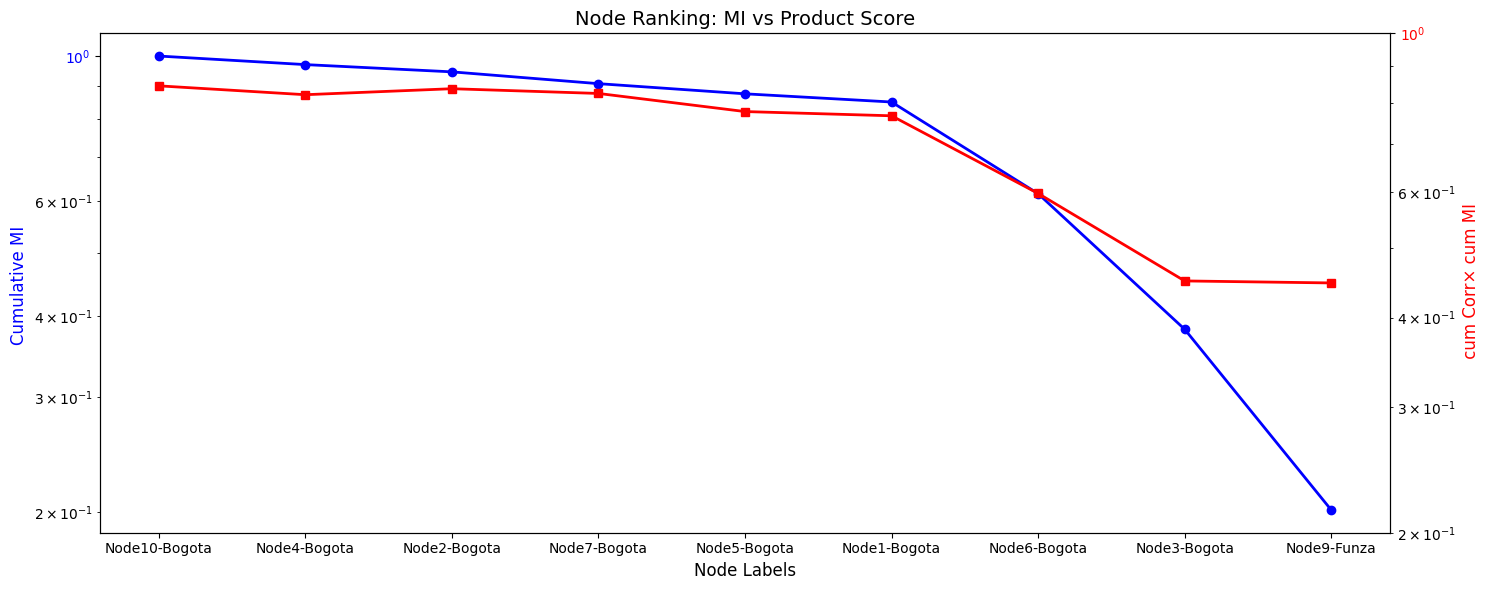

In [15]:
# Convert pxx_node into the expected format for MI_matrix
vectors_by_node = {name: data["pxx"] for name, data in pxx_node.items()}

scores_MI, used_range = MI_matrix(
    vectors_by_node,
    bins=N_BINS,
    qrange=(1, 99),
    base=2.0,
    normalized=False,   # set True if you want NMI
)

# -----------------------
# combined cumulative  ranking over all rows
# -----------------------

multiplied_scores = multiply_similarity_scores(ranked_cum_corr, scores_MI)

print("\n Nodes ranked by Product Score:")
print("=" * 70)
print(f"{'Rank':<6} {'Label':<20} {'Corr':<12} {'MI':<12} {'Product':<12}")
print("-" * 70)

for i, row in multiplied_scores.head(10).iterrows():
    print(f"{i+1:<6} {row['label']:<20} "
          f"{row['correlation']:>11.4f} {row['MI']:>11.4f} {row['product']:>11.4f}")

fig, ax1 = plt.subplots(figsize=(15, 6))

x_pos = np.arange(len(scores_MI.index))
plot_labels = scores_MI.index.tolist()

# MI on left axis
ax1.semilogy(x_pos, scores_MI.values, 'b-o', label='MI Score', linewidth=2, markersize=6)
ax1.set_xlabel('Node Labels', fontsize=12)
ax1.set_ylabel('Cumulative MI ', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# Product on right axis
ax2 = ax1.twinx()
product_dict = dict(zip(multiplied_scores['label'], multiplied_scores['product']))
product_vals = [product_dict.get(l, np.nan) for l in plot_labels]
ax2.semilogy(x_pos, product_vals, 'r-s', label='Product', linewidth=2, markersize=6)
ax2.set_ylabel(' cum Corr× cum MI', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

plt.xticks(range(len(scores_MI.index)), scores_MI.index, rotation=45, ha="right")
plt.ylim(0.2,1)
plt.title('Node Ranking: MI vs Product Score', fontsize=14)
plt.grid(True, alpha=0.54)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>